In [87]:
import pandas as pd
import numpy as np
import altair as alt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans


In [88]:
!pip install cohere

In [89]:
import cohere
co = cohere.ClientV2("JVNvur73jskGr8rS98JubjUfi870n4ZLSavn5FCa")

In [90]:
# Load the dataset to a dataframe
df_orig = pd.read_csv('https://raw.githubusercontent.com/cohere-ai/notebooks/main/notebooks/data/atis_intents_train.csv', names=['intent','query'])

# Take a small sample for illustration purposes
sample_classes = ['atis_airfare', 'atis_airline', 'atis_ground_service']
df = df_orig.sample(frac=0.1, random_state=30)
df = df[df.intent.isin(sample_classes)]
df_orig = df_orig.drop(df.index)
df.reset_index(drop=True,inplace=True)

# Remove unnecessary column
intents = df['intent'] #save for a later need
df.drop(columns=['intent'], inplace=True)

In [91]:
def get_embeddings(texts, model="embed-v4.0", input_type="search_document"):
    output = co.embed(
        texts=texts,
        model=model,
        input_type=input_type,
        embedding_types=["float"]
    )
    return output.embeddings.float

df['query_embeds'] = get_embeddings(df['query'].tolist())
df['query_embeds']

,query_embeds
0,"[0.053780045, -0.021647315, -0.0021562753, -0...."
1,"[0.02168091, 0.010757703, -0.0143160205, -0.01..."
2,"[-0.053413574, 0.029620254, -0.004734385, 0.00..."
3,"[0.048149295, 0.017207718, -0.018823465, -0.01..."
4,"[0.04717391, -0.003194067, 0.0089679565, -0.05..."
...,...
86,"[0.027204221, -0.0014506219, -0.021374745, -0...."
87,"[0.043988146, 0.012878109, 0.05527458, 0.02271..."
88,"[0.026353575, -0.0012941487, -0.009490424, -0...."
89,"[0.055167872, -0.0031310811, -0.005374811, -0...."


In [92]:
df['query']

,query
0,which airlines fly from boston to washington ...
1,show me the airlines that fly between toronto...
2,show me round trip first class tickets from n...
3,i'd like the lowest fare from denver to pitts...
4,show me a list of ground transportation at bo...
...,...
86,what ground transportation is there in atlanta
87,can i take a single airline from la to charlo...
88,what is the cost for a one way trip from pitt...
89,what ground transportation is available in ba...


In [93]:
df['query_embeds']

,query_embeds
0,"[0.053780045, -0.021647315, -0.0021562753, -0...."
1,"[0.02168091, 0.010757703, -0.0143160205, -0.01..."
2,"[-0.053413574, 0.029620254, -0.004734385, 0.00..."
3,"[0.048149295, 0.017207718, -0.018823465, -0.01..."
4,"[0.04717391, -0.003194067, 0.0089679565, -0.05..."
...,...
86,"[0.027204221, -0.0014506219, -0.021374745, -0...."
87,"[0.043988146, 0.012878109, 0.05527458, 0.02271..."
88,"[0.026353575, -0.0012941487, -0.009490424, -0...."
89,"[0.055167872, -0.0031310811, -0.005374811, -0...."


In [94]:
for i in range(10):
    print(df['query'][i])

 which airlines fly from boston to washington dc via other cities
 show me the airlines that fly between toronto and denver
 show me round trip first class tickets from new york to miami
 i'd like the lowest fare from denver to pittsburgh
 show me a list of ground transportation at boston airport
 show me boston ground transportation
 of all airlines which airline has the most arrivals in atlanta
 what ground transportation is available in boston
 i would like your rates between atlanta and boston on september third
 which airlines fly between boston and pittsburgh


In [95]:
for i in range(10):
    print(cosine_similarity(np.array(df['query_embeds'][0]).reshape(1, -1), np.array(df['query_embeds'][i]).reshape(1, -1)))

[[1.]]
[[0.38611747]]
[[0.29166823]]
[[0.29507008]]
[[0.37192785]]
[[0.33664606]]
[[0.50648539]]
[[0.40912821]]
[[0.3230571]]
[[0.6618792]]


In [96]:
for i in range(10):
    print(cosine_similarity(np.array(df['query_embeds'][1]).reshape(1, -1), np.array(df['query_embeds'][i]).reshape(1, -1)))

[[0.38611747]]
[[1.]]
[[0.27443638]]
[[0.40058422]]
[[0.20975035]]
[[0.20949552]]
[[0.34335507]]
[[0.18459434]]
[[0.17749006]]
[[0.45850468]]


In [97]:
for i in range(10):
    print(cosine_similarity(np.array(df['query_embeds'][3]).reshape(1, -1), np.array(df['query_embeds'][i]).reshape(1, -1)))

[[0.29507008]]
[[0.40058422]]
[[0.38801888]]
[[1.]]
[[0.16304626]]
[[0.28230605]]
[[0.29391138]]
[[0.24368627]]
[[0.43079134]]
[[0.44669281]]


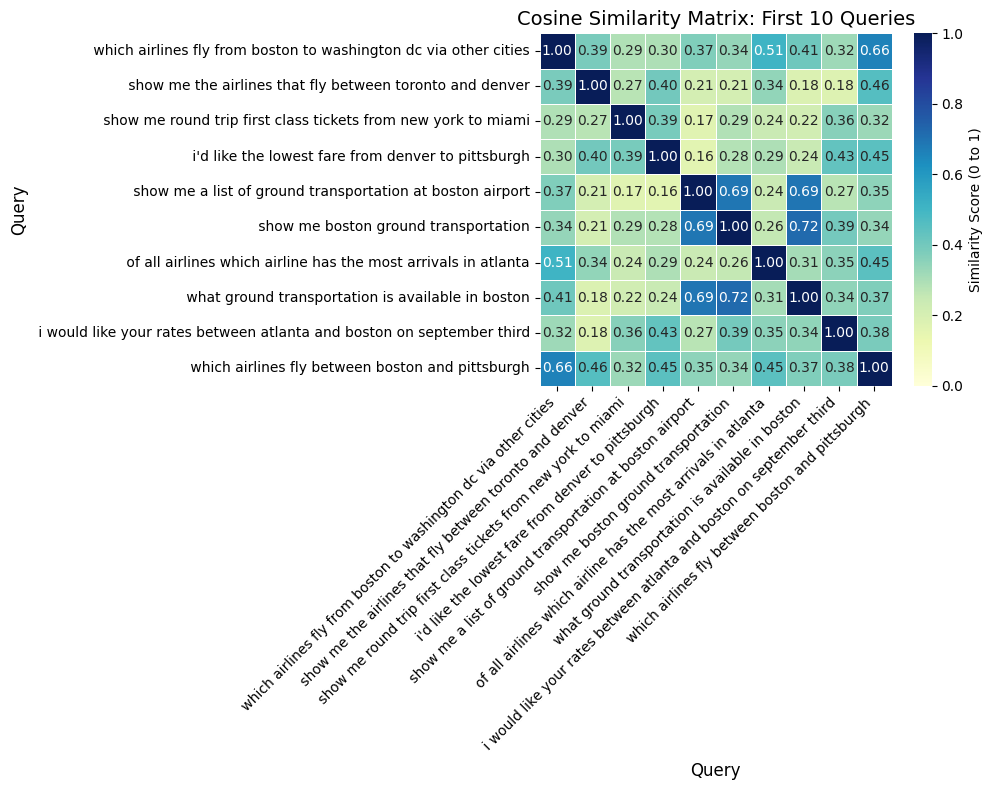

In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# 1. Prepare Data
# 'query_embeds' ko numpy array mein convert karein
embeds_array = np.array(df['query_embeds'].tolist())

# 2. Calculate Cosine Similarity Matrix
# Har query ko har doosri query se compare karein
# Result ek square matrix hoga (10x10 agar 10 queries hain)
similarity_matrix = cosine_similarity(embeds_array)

# 3. Create DataFrame for Heatmap
# Rows aur Columns ko query text se label karein
df_sim = pd.DataFrame(similarity_matrix, index=df['query'], columns=df['query'])

# 4. Select ONLY the first 10 rows/cols
df_sim_subset = df_sim.iloc[:10, :10]

# 5. Plotting the Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(df_sim_subset,
            cmap='YlGnBu',       # Yellow-Green-Blue scale (Yellow=Low, Blue=High)
            linewidths=.5,
            cbar_kws={'label': 'Similarity Score (0 to 1)'},
            annot=True,          # Box ke andar number dikhayein (e.g., 0.85)
            fmt=".2f",           # 2 decimal places
            vmin=0, vmax=1)      # Scale 0 se 1 tak fix karein

plt.title('Cosine Similarity Matrix: First 10 Queries', fontsize=14)
plt.xlabel('Query', fontsize=12)
plt.ylabel('Query', fontsize=12)
plt.xticks(rotation=45, ha='right') # Labels ko thoda tilt karein taaki padhne mein aasani ho
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [99]:
# Function to return the principal components
def get_pc(arr, n):
    pca = PCA(n_components=n)
    embeds_transform = pca.fit_transform(arr)
    return embeds_transform

# Reduce embeddings to 10 principal components to aid visualization
embeds = np.array(df['query_embeds'].tolist())
embeds_pc = get_pc(embeds, 10)

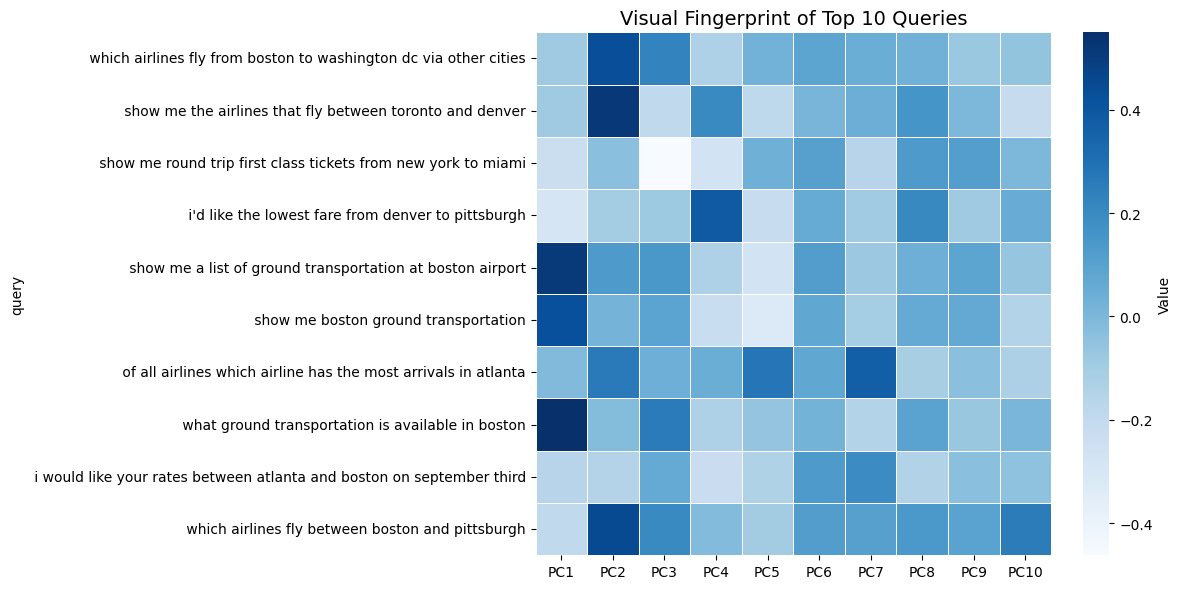

In [100]:
top_n = 10
df_heatmap_subset = df_heatmap.head(top_n)

# Plot results
plt.figure(figsize=(12, top_n * 0.6))
sns.heatmap(df_heatmap_subset, cmap='Blues', linewidths=.5, cbar_kws={'label': 'Value'})
plt.title(f'Visual Fingerprint of Top {top_n} Queries', fontsize=14)
plt.tight_layout()
plt.show()

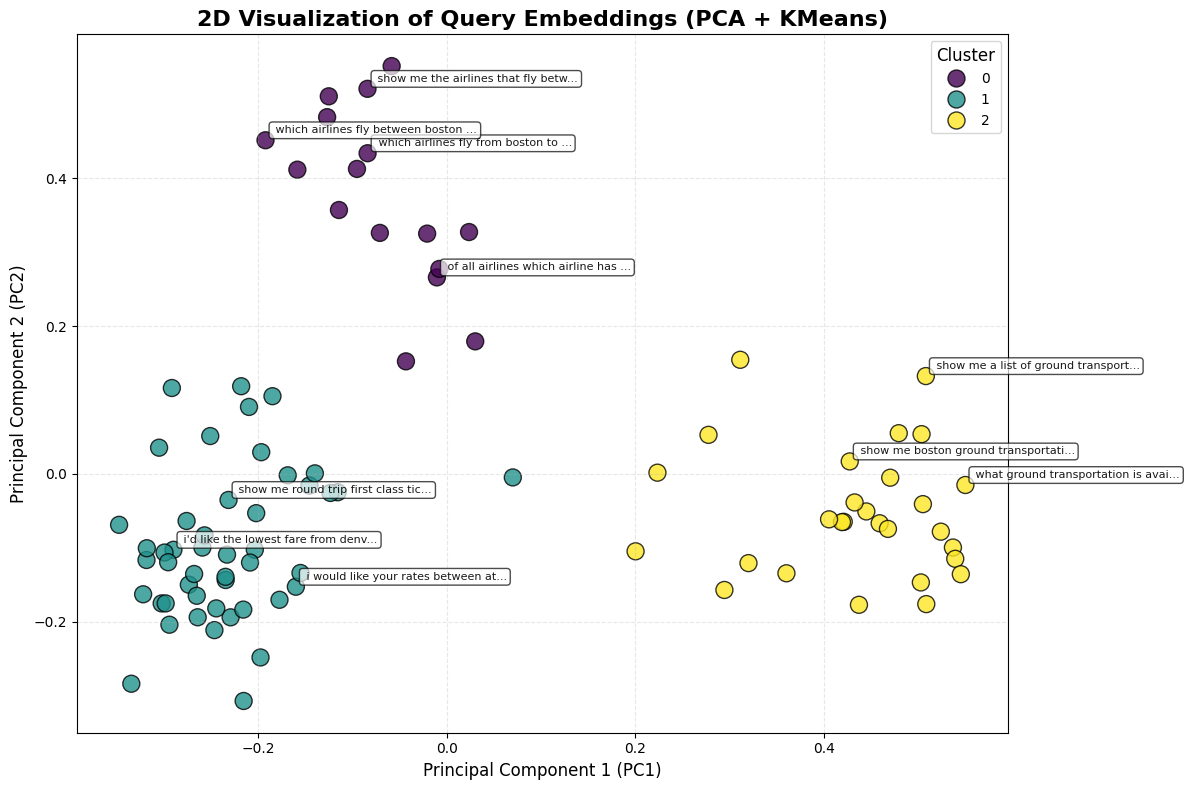

In [101]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Step 1: Prepare the data
# Convert the 'query_embeds' column (list of embeddings) into a NumPy array
# Ensure 'df' has the 'query_embeds' column from previous steps
embeds_array = np.array(df['query_embeds'].tolist())

# Step 2: Perform PCA to reduce dimensions to 2D
# This compresses 1536 dimensions into 2 principal components (x, y)
pca = PCA(n_components=2)
embeds_2d = pca.fit_transform(embeds_array)

# Step 3: Create a DataFrame for plotting
df_plot = pd.DataFrame(embeds_2d, columns=['x', 'y'])
df_plot['query'] = df['query']  # Store original query text for labels

# Optional: Perform KMeans clustering to group similar queries
# We use 3 clusters because we filtered for 3 intents (atis_airfare, atis_airline, atis_ground_service)
# If you want more/fewer groups, change n_clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_plot['cluster'] = kmeans.fit_predict(embeds_array)

# Step 4: Plot the 2D Scatter Plot
plt.figure(figsize=(12, 8))

# Create a scatter plot colored by cluster
scatter = sns.scatterplot(
    data=df_plot,
    x='x',
    y='y',
    hue='cluster',
    palette='viridis',  # Color scheme: green-blue-purple
    s=150,              # Size of the dots
    alpha=0.8,          # Transparency
    edgecolor='k',      # Black border around dots
    legend='full'
)

# Add titles and labels
plt.title('2D Visualization of Query Embeddings (PCA + KMeans)', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# Add legend
plt.legend(title='Cluster', loc='best', title_fontsize='12')

# Annotate the first 10 queries with their text (to identify points)
# This helps in understanding which point corresponds to which query
for i, row in df_plot.head(10).iterrows():
    plt.annotate(
        row['query'][:35] + '...',  # Truncate long queries to 35 chars
        (row['x'], row['y']),
        fontsize=8,
        alpha=0.9,
        xytext=(5, 5),              # Offset text slightly from the point
        textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [102]:
def get_embeddings(texts, model="embed-v4.0", input_type="search_document"):
    output = co.embed(
        model=model,
        input_type=input_type,
        texts=texts,
        embedding_types=["float"],
    )
    return output.embeddings.float

df['query_embeds'] = get_embeddings(df['query'].tolist())
embeds = np.array(df['query_embeds'].tolist())

In [103]:
# Define new query
new_query = "How can I find a taxi or a bus when the plane lands?"

# Get embeddings of the new query
new_query_embeds = get_embeddings([new_query], input_type="search_query")[0]


In [108]:
# Calculate cosine similarity between the search query and existing queries
def get_similarity(target, candidates):
    # Turn list into array
    candidates = np.array(candidates)
    target = np.expand_dims(np.array(target),axis=0)

    # Calculate cosine similarity
    sim = cosine_similarity(target, candidates)
    sim = np.squeeze(sim).tolist()
    sort_index = np.argsort(sim)[::-1]
    sort_score = [sim[i] for i in sort_index]
    similarity_scores = zip(sort_index,sort_score)

    # Return similarity scores
    return similarity_scores

# Get the similarity between the search query and existing queries
similarity = get_similarity(new_query_embeds, embeds)

In [109]:
# View the top 5 articles
print('Query:')
print(new_query,'\n')

print('Most Similar Documents:')
for idx, sim in similarity:
    print(f'Similarity: {sim:.2f};', df.iloc[idx]['query'])

Query:
How can I find a taxi or a bus when the plane lands? 

Most Similar Documents:
Similarity: 0.41;  can you help me with ground transportation information i need to get from the airport in philadelphia to downtown philadelphia
Similarity: 0.41;  can you find out about the ground transportation available in atlanta
Similarity: 0.40;  i need your help with information on ground transportation from the airport in philadelphia to downtown
Similarity: 0.38;  i need to get downtown from the denver airport
Similarity: 0.35;  is there ground transportation in boston from the airport
Similarity: 0.35;  what type of ground transportation is available in washington
Similarity: 0.35;  what ground transportation is available in san francisco
Similarity: 0.34;  what ground transportation is available in boston
Similarity: 0.34;  what kind of ground transportation is available in las vegas
Similarity: 0.33;  and i'll need ground transportation for tuesday july sixth to wednesday july seventh in 

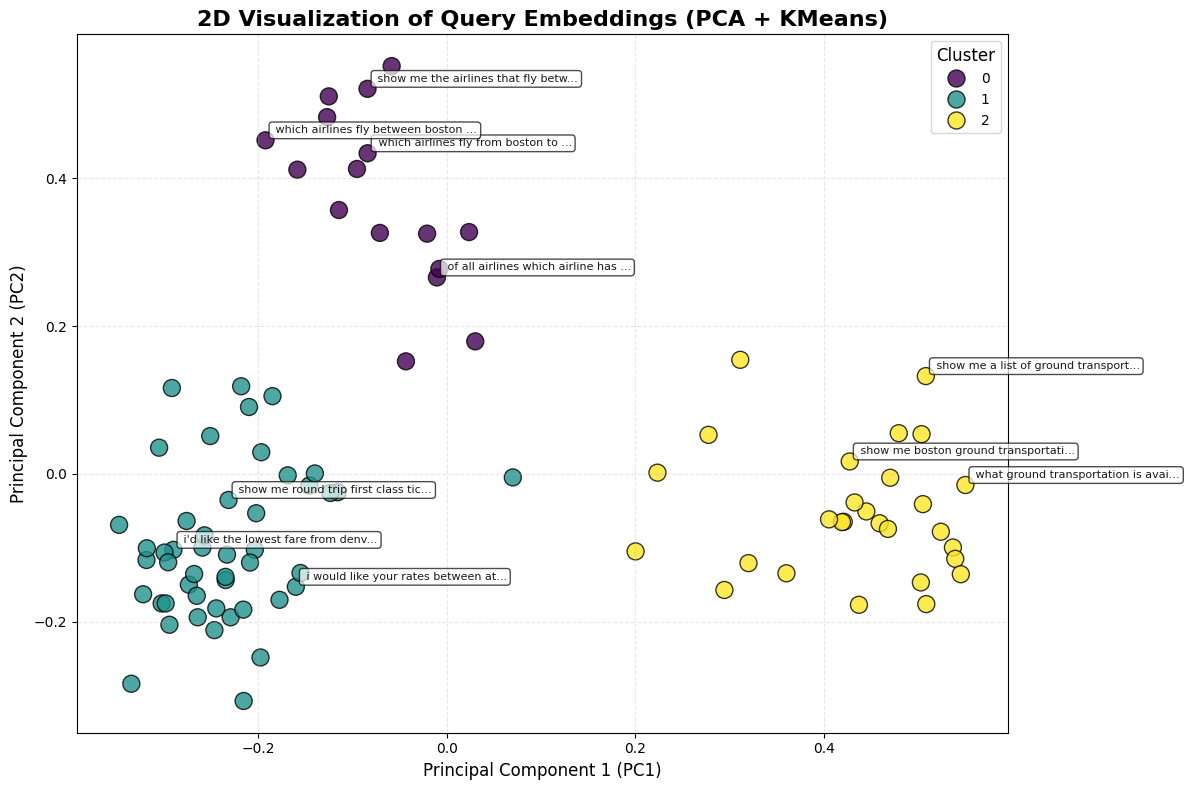

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Convert embeddings to numpy array
embeds_array = np.array(df['query_embeds'].tolist())

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
embeds_2d = pca.fit_transform(embeds_array)

# Create DataFrame for plotting
df_plot = pd.DataFrame(embeds_2d, columns=['x', 'y'])
df_plot['query'] = df['query']

# Optional: KMeans clustering to group similar queries
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_plot['cluster'] = kmeans.fit_predict(embeds_array)

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_plot,
    x='x',
    y='y',
    hue='cluster',
    palette='viridis',
    s=150,
    alpha=0.8,
    edgecolor='k'
)

plt.title('2D Visualization of Query Embeddings (PCA + KMeans)', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='Cluster', loc='best', title_fontsize=12)

# Annotate first 10 queries
for i, row in df_plot.head(10).iterrows():
    plt.annotate(
        row['query'][:35] + '...',
        (row['x'], row['y']),
        fontsize=8,
        alpha=0.9,
        xytext=(5, 5),
        textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
plt.show()

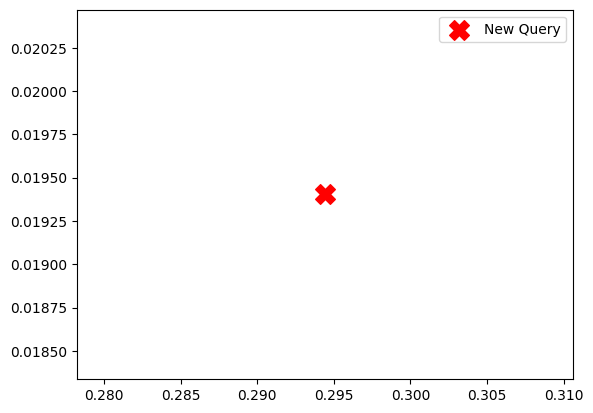

In [116]:
new_query = "How can I find a taxi or a bus when the plane lands?"
new_query_embeds = get_embeddings([new_query], input_type="search_query")[0]

# Reduce new query to 2D using PCA
new_query_2d = pca.transform([new_query_embeds])

# Plot on same figure
plt.scatter(new_query_2d[0][0], new_query_2d[0][1], c='red', marker='X', s=200, label='New Query')
plt.legend()
plt.show()